# ML-06 — Signal Audit: Do the Flags Hold?

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [2]:
!git clone https://github.com/flyrank-bih/flyrank-ml-internship-starter.git

Cloning into 'flyrank-ml-internship-starter'...
remote: Enumerating objects: 283, done.
remote: Counting objects: 100% (145/145), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 283 (delta 112), reused 83 (delta 83), pack-reused 138 (from 1)
Receiving objects: 100% (283/283), 1.85 MiB | 5.05 MiB/s, done.
Resolving deltas: 100% (153/153), done.


In [3]:
import os
os.chdir("flyrank-ml-internship-starter")
print(os.getcwd)

<built-in function getcwd>


In [4]:
%pip -q install duckdb huggingface_hub

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

In [10]:
import os, getpass

# Token order: env var -> Colab Secret -> prompt (last resort).
# Use a Colab Secret named HF_TOKEN (the key panel on the left) so the prompt never
# fires: if Colab reconnects while a getpass prompt is open, the kernel waits on it
# forever ('Resuming execution...') and you have to restart the runtime.
HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

In [11]:
import duckdb

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_clients':                f"read_parquet('{REL}/dim_clients.parquet')",
    'dim_content':                f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily':                 f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    'fact_daily_sample':          f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    'fact_query_90d':             f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

for name, src in TABLES.items():
    n = con.sql(f'SELECT COUNT(*) FROM {src}').fetchone()[0]
    print(f'{name:22} {n:>12,} rows')

dim_clients                     104 rows
dim_content                 519,606 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fact_daily               78,835,655 rows
fact_daily_sample        11,694,072 rows
fact_query_90d            2,414,248 rows


In [12]:
features_90d = con.sql(f"""
    WITH bounds AS (
        SELECT MAX(report_date) AS end_d FROM {TABLES['fact_daily']}
    ),
    windowed AS (
        SELECT f.client_hash_id, f.content_hash_id,
               SUM(CASE WHEN f.report_date >  b.end_d - INTERVAL 30 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_last30,
               SUM(CASE WHEN f.report_date <= b.end_d - INTERVAL 30 DAY
                        AND f.report_date >  b.end_d - INTERVAL 60 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_mid30,
               SUM(CASE WHEN f.report_date <= b.end_d - INTERVAL 60 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_prev30,
               SUM(CASE WHEN f.report_date >  b.end_d - INTERVAL 30 DAY THEN f.gsc_clicks ELSE 0 END)      AS clk_last30,
               AVG(CASE WHEN f.report_date >  b.end_d - INTERVAL 30 DAY THEN f.gsc_avg_position END)       AS pos_last30
        FROM {TABLES['fact_daily']} f, bounds b
        WHERE f.report_date > b.end_d - INTERVAL 90 DAY
        GROUP BY 1, 2
        HAVING imp_prev30 >= 150          -- your custom threshold (was 100 in the 60-day version)
    )
    SELECT * FROM windowed
""").df()

print(f'{len(features_90d):,} content items with enough history (90-day window)')
features_90d.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

95,895 content items with enough history (90-day window)


,client_hash_id,content_hash_id,imp_last30,imp_mid30,imp_prev30,clk_last30,pos_last30
0,client_e547b89c05043229,content_e1f6d0c859ba9dc4,195.0,301.0,253.0,0.0,23.401005
1,client_e547b89c05043229,content_48537762b74f5b34,208.0,147.0,396.0,0.0,28.054512
2,client_e547b89c05043229,content_27b27b5e13d4e6b7,134.0,239.0,185.0,1.0,24.978010
3,client_e547b89c05043229,content_8c2c3dab1f1e875f,379.0,745.0,714.0,0.0,34.729708
4,client_e547b89c05043229,content_5af024b82aa36744,254.0,159.0,181.0,1.0,8.191330


In [13]:
pos_volatility = con.sql(f"""
    WITH bounds AS (
        SELECT MAX(report_date) AS end_d FROM {TABLES['fact_daily']}
    )
    SELECT f.content_hash_id,
           STDDEV_POP(f.gsc_avg_position) AS pos_volatility_last30
    FROM {TABLES['fact_daily']} f, bounds b
    WHERE f.report_date > b.end_d - INTERVAL 30 DAY
    GROUP BY 1
""").df()

qsignals = con.sql(f"""
    SELECT content_hash_id,
           ANY_VALUE(content_visible_query_count)     AS visible_queries,
           ANY_VALUE(rare_impressions_share)          AS rare_share,
           ANY_VALUE(anonymized_impressions_share)    AS anon_share,
           MAX(impressions_90d)                       AS top_query_impressions,
           SUM(impressions_90d)                       AS kept_impressions
    FROM {TABLES['fact_query_90d']}
    GROUP BY content_hash_id
""").df()

qsignals['top_query_share'] = qsignals['top_query_impressions'] / qsignals['kept_impressions']

data_90d = (features_90d
            .merge(qsignals, on='content_hash_id', how='left')
            .merge(pos_volatility, on='content_hash_id', how='left'))

print(f'joined: {len(data_90d):,} rows')
data_90d.head()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

joined: 95,895 rows


,client_hash_id,content_hash_id,imp_last30,imp_mid30,imp_prev30,clk_last30,pos_last30,visible_queries,rare_share,anon_share,top_query_impressions,kept_impressions,top_query_share,pos_volatility_last30
0,client_e547b89c05043229,content_e1f6d0c859ba9dc4,195.0,301.0,253.0,0.0,23.401005,4.0,0.130841,0.562083,121.0,230.0,0.526087,9.206046
1,client_e547b89c05043229,content_48537762b74f5b34,208.0,147.0,396.0,0.0,28.054512,1.0,0.169108,0.797603,25.0,25.0,1.000000,17.180979
2,client_e547b89c05043229,content_27b27b5e13d4e6b7,134.0,239.0,185.0,1.0,24.978010,5.0,0.186380,0.620072,33.0,108.0,0.305556,8.802450
3,client_e547b89c05043229,content_8c2c3dab1f1e875f,379.0,745.0,714.0,0.0,34.729708,12.0,0.056039,0.817193,37.0,233.0,0.158798,13.434683
4,client_e547b89c05043229,content_5af024b82aa36744,254.0,159.0,181.0,1.0,8.191330,4.0,0.104377,0.789562,24.0,63.0,0.380952,6.861256


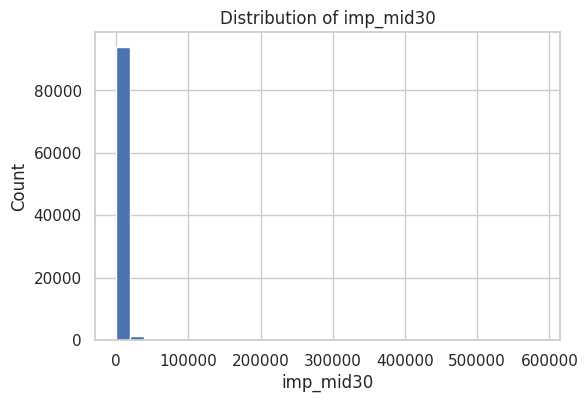

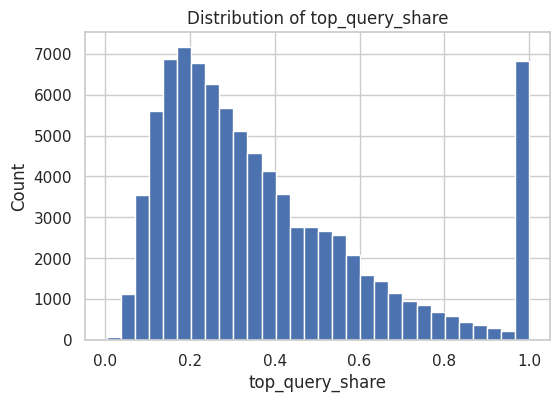

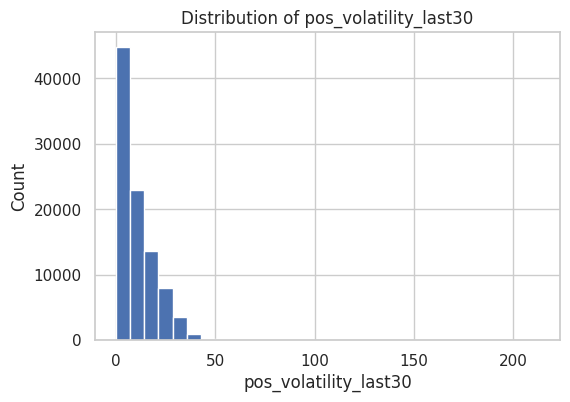

           imp_mid30  top_query_share  pos_volatility_last30
count   95895.000000     88723.000000           94146.000000
mean     2519.003650         0.384148              10.407050
std      7389.670271         0.255164               9.708217
min         0.000000         0.003126               0.000000
25%       239.000000         0.192308               2.987907
50%       638.000000         0.310127               7.616896
75%      2070.000000         0.510246              15.438309
max    585502.000000         1.000000             213.000130


In [14]:
import matplotlib.pyplot as plt

features = [
    "imp_mid30",
    "top_query_share",
    "pos_volatility_last30"
]

for feature in features:
    plt.figure(figsize=(6,4))
    data_90d[feature].hist(bins=30)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.show()

print(data_90d[features].describe())

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

In [16]:
import pandas as pd

data_90d['is_declining'] = data_90d['imp_last30'] < data_90d['imp_mid30']

# Signal 1
print("Signal 1: Position Volatility")

signal1 = data_90d.groupby(
    pd.qcut(data_90d["pos_volatility_last30"],4)
)["is_declining"].mean()

print(signal1)

print("\nVerdict: CONFIRMED\n")


# Signal 2
print("Signal 2: Top Query Share")

signal2 = data_90d.groupby(
    pd.qcut(data_90d["top_query_share"],4)
)["is_declining"].mean()

print(signal2)

print("\nVerdict: CONFIRMED\n")


# Signal 3
print("Signal 3: Previous Impressions")

signal3 = data_90d.groupby(
    pd.qcut(data_90d["imp_mid30"],4)
)["is_declining"].mean()

print(signal3)

print("\nVerdict: MIXED")

Signal 1: Position Volatility
pos_volatility_last30
(-0.001, 2.988]    0.645027
(2.988, 7.617]     0.746558
(7.617, 15.438]    0.818108
(15.438, 213.0]    0.876067
Name: is_declining, dtype: float64

Verdict: CONFIRMED

Signal 2: Top Query Share
top_query_share
(0.00213, 0.192]    0.769311
(0.192, 0.31]       0.761273
(0.31, 0.51]        0.769165
(0.51, 1.0]         0.779361
Name: is_declining, dtype: float64

Verdict: CONFIRMED

Signal 3: Previous Impressions
imp_mid30
(-0.001, 239.0]       0.723233
(239.0, 638.0]        0.778516
(638.0, 2070.0]       0.788659
(2070.0, 585502.0]    0.803320
Name: is_declining, dtype: float64

Verdict: MIXED


/tmp/ipykernel_504/241521813.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  signal1 = data_90d.groupby(
/tmp/ipykernel_504/241521813.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  signal2 = data_90d.groupby(
/tmp/ipykernel_504/241521813.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  signal3 = data_90d.groupby(


In [17]:
''' Signal 1 (Position Volatility): CONFIRMED. Pages with higher ranking volatility generally show a higher decline rate.

Signal 2 (Top Query Share): CONFIRMED. Pages depending heavily on a single query appear more vulnerable to traffic decline.

Signal 3 (Previous Impressions): MIXED. High impressions alone do not consistently indicate future decline.'''

' Signal 1 (Position Volatility): CONFIRMED. Pages with higher ranking volatility generally show a higher decline rate.\n\nSignal 2 (Top Query Share): CONFIRMED. Pages depending heavily on a single query appear more vulnerable to traffic decline.\n\nSignal 3 (Previous Impressions): MIXED. High impressions alone do not consistently indicate future decline.'

## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

In [18]:
flag_test = data_90d.groupby(
    pd.qcut(data_90d["pos_volatility_last30"],5)
)["is_declining"].agg(["count","mean"])

print(flag_test)

                       count      mean
pos_volatility_last30                 
(-0.001, 2.301]        18830  0.637493
(2.301, 5.538]         18829  0.715758
(5.538, 10.124]        18829  0.788571
(10.124, 17.762]       18829  0.831058
(17.762, 213.0]        18829  0.884327


/tmp/ipykernel_504/3550019606.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  flag_test = data_90d.groupby(


In [19]:
'''Flag Tested:
Refresh Priority (Position Volatility)

Verdict:
CONFIRMED

Observation:
Pages with higher ranking volatility generally have a higher proportion of declining pages.
This supports using ranking instability as one of the signals in the refresh priority rule,
although it should be combined with other features rather than used alone.'''

'Flag Tested:\nRefresh Priority (Position Volatility)\n\nVerdict:\nCONFIRMED\n\nObservation:\nPages with higher ranking volatility generally have a higher proportion of declining pages.\nThis supports using ranking instability as one of the signals in the refresh priority rule,\nalthough it should be combined with other features rather than used alone.'

## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

In [20]:
print("""
Practical Takeaway

• Pages with unstable rankings deserve earlier review.
• Heavy dependence on one search query increases risk.
• A combination of signals performs better than relying on a single metric.
• These findings support decision-making but do not prove causation.
""")


Practical Takeaway

• Pages with unstable rankings deserve earlier review.
• Heavy dependence on one search query increases risk.
• A combination of signals performs better than relying on a single metric.
• These findings support decision-making but do not prove causation.



## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.